# Class Imbalance Handling — FraudBusters

Techniques borrowed from reviewing a similarly-imbalanced fraud project (ULB Credit Card Fraud dataset, 0.17% fraud) and applied to our own data (3.5% fraud).

Covers:
1. Confirming the imbalance
2. Downsampling (undersample the majority class)
3. SMOTE (oversample the minority class synthetically)
4. Comparing Logistic Regression performance across original / downsampled / SMOTE versions
5. Threshold tuning (picking a cutoff other than 0.5 to maximize F1)

Run this on your cleaned dataset (`train_clean.csv` from the null-handling step).

## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                              f1_score, classification_report, confusion_matrix)

# pip install imbalanced-learn --break-system-packages   (if not already installed)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

DATA_DIR = r"C:\Users\aylin\OneDrive\Desktop\INFO\INFO442\Project"
%matplotlib inline
sns.set(style="whitegrid")

## 2. Load your cleaned data

In [5]:
with open(DATA_DIR + r"\train_clean.csv", 'r', encoding='utf-8', errors='replace') as f:
    for i, line in enumerate(f):
        if i == 590542:  # 0-indexed, so this is "line 590543"
            print(line)
            break

df = pd.read_csv(DATA_DIR + r"\train_clean.csv", on_bad_lines='skip')
print(df.shape)
print(df['isFraud'].value_counts(normalize=True) * 100)

3566129,0,15437917,59.0,W,9513,555.0,150.0,visa,226.0,debit,264.0,87.0,59.0,-999.0,missing,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,58.0,2.0,207.0,207.0,22.0,26.0,10.0,0.0,0.0,37.875,0.6666659712791443,206.0,372.0,0.0,0.0,0.0,207.0,T,F,F,M1,T,F,missing,missing,missing,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,1.0,1.0,2.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,270.0,0.0,0.0,0.0,0.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999

C:\Users\aylin\AppData\Local\Temp\ipykernel_15624\3649508145.py:7: DtypeWarning: Columns (25,26,27,28,29,30,31,32,33,302,305,306,313,317,318,321,323,324,325,326,328,329,330) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_DIR + r"\train_clean.csv", on_bad_lines='skip')


(590541, 347)
isFraud
0.0    96.500836
1.0     3.499164
Name: proportion, dtype: float64


## 3. Confirm the imbalance

This just visualizes what you already know (3.5% fraud) side by side with the ULB dataset's 0.17% for context.

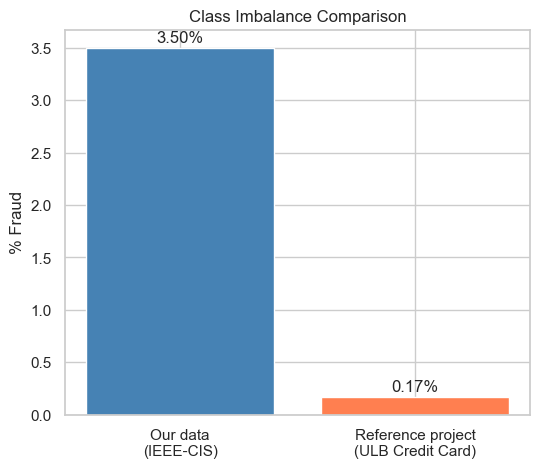

Our fraud rate: 3.50%
Reference project's fraud rate: 0.17%
Ours is less extreme, but still imbalanced enough that a model could 'cheat'
by just predicting not-fraud every time and still look highly accurate.


In [7]:
fraud_pct = df['isFraud'].mean() * 100

plt.figure(figsize=(6, 5))
labels = ['Our data\n(IEEE-CIS)', 'Reference project\n(ULB Credit Card)']
values = [fraud_pct, 0.172]
plt.bar(labels, values, color=['steelblue', 'coral'])
plt.ylabel('% Fraud')
plt.title('Class Imbalance Comparison')
for i, v in enumerate(values):
    plt.text(i, v + 0.05, f'{v:.2f}%', ha='center')
plt.show()

print(f"Our fraud rate: {fraud_pct:.2f}%")
print("Reference project's fraud rate: 0.17%")
print("Ours is less extreme, but still imbalanced enough that a model could 'cheat'")
print("by just predicting not-fraud every time and still look highly accurate.")

## 4. Prepare features

Quick prep for modeling: drop non-feature columns, one-hot encode any remaining categoricals, scale numeric features (required for logistic regression), and split into train/test.

Adjust the `drop_cols` list if your cleaned data has different ID/date columns than expected.

In [9]:
drop_cols = [c for c in ['TransactionID', 'TransactionDT', 'Date'] if c in df.columns]

X = df.drop(columns=['isFraud'] + drop_cols)
y = df['isFraud']

obj_cols = X.select_dtypes(include='object').columns
LOW_CARD_THRESHOLD = 50
high_card_cols = [c for c in obj_cols if X[c].nunique() > LOW_CARD_THRESHOLD]
X = X.drop(columns=high_card_cols)

X = pd.get_dummies(X, drop_first=True)
X = X.astype('float32')
print("Shape after encoding:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Drop zero-variance columns (found within the training split)
train_std = X_train.std()
zero_var_cols = train_std[train_std == 0].index.tolist()
print("Dropping zero-variance columns:", zero_var_cols)
X_train = X_train.drop(columns=zero_var_cols)
X_test = X_test.drop(columns=zero_var_cols)

# Safety net: check for and fix any remaining NaN values, regardless of source
print("\nNaN count in X_train before imputation:", X_train.isna().sum().sum())
print("NaN count in X_test before imputation:", X_test.isna().sum().sum())

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype('float32')
X_test_scaled = scaler.transform(X_test).astype('float32')

print("\nAny NaN in X_train_scaled?", np.isnan(X_train_scaled).any())
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Fraud % in train:", y_train.mean() * 100)
print("Fraud % in test:", y_test.mean() * 100)

Shape after encoding: (590541, 489)
Dropping zero-variance columns: ['id_09_-30.0', 'id_09_25.0', 'id_14_360.0', 'id_22_23.0', 'id_24_23.0']

NaN count in X_train before imputation: 3
NaN count in X_test before imputation: 0

Any NaN in X_train_scaled? False
Train shape: (472432, 484)
Test shape: (118109, 484)
Fraud % in train: 3.499127916821892
Fraud % in test: 3.499309959444242


## 5. Baseline: Logistic Regression on the original (imbalanced) data

This is your reference point — how the model performs with no imbalance handling at all.

In [11]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

y_pred_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]
y_pred = baseline_model.predict(X_test_scaled)

print("=== Baseline (original, imbalanced) ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"F1 (default 0.5 threshold): {f1_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred))

=== Baseline (original, imbalanced) ===
ROC-AUC: 0.8406
Average Precision: 0.3416
F1 (default 0.5 threshold): 0.2289

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98    113976
         1.0       0.75      0.14      0.23      4133

    accuracy                           0.97    118109
   macro avg       0.86      0.57      0.61    118109
weighted avg       0.96      0.97      0.96    118109



In [12]:
from imblearn.under_sampling import RandomUnderSampler

In [13]:
print('X_train_scaled' in dir())
print('df' in dir())

True
True


## 6. Downsampling

Randomly removes rows from the majority class (not-fraud) until the classes are balanced. Fast, but throws away real data.

In [15]:
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train_scaled, y_train)

print("Downsampled train shape:", X_train_under.shape)
print("Fraud % after downsampling:", y_train_under.mean() * 100)

model_under = LogisticRegression(max_iter=1000, random_state=42)
model_under.fit(X_train_under, y_train_under)

y_pred_proba_under = model_under.predict_proba(X_test_scaled)[:, 1]
y_pred_under = model_under.predict(X_test_scaled)

print("\n=== Downsampled ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_under):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_pred_proba_under):.4f}")
print(f"F1 (default 0.5 threshold): {f1_score(y_test, y_pred_under):.4f}")

Downsampled train shape: (33062, 484)
Fraud % after downsampling: 50.0

=== Downsampled ===
ROC-AUC: 0.8464
Average Precision: 0.2628
F1 (default 0.5 threshold): 0.2005


## 7. SMOTE (Synthetic Minority Over-sampling)

Instead of removing majority-class rows, this generates synthetic new fraud examples by interpolating between existing fraud cases. Keeps all your real data, adds synthetic minority examples.

Note: can be slow on wide datasets (many columns) — if this takes too long, try SMOTE on a subset of columns or rows first.

In [17]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("SMOTE train shape:", X_train_smote.shape)
print("Fraud % after SMOTE:", y_train_smote.mean() * 100)

model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_proba_smote = model_smote.predict_proba(X_test_scaled)[:, 1]
y_pred_smote = model_smote.predict(X_test_scaled)

print("\n=== SMOTE ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_smote):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_pred_proba_smote):.4f}")
print(f"F1 (default 0.5 threshold): {f1_score(y_test, y_pred_smote):.4f}")

SMOTE train shape: (911802, 484)
Fraud % after SMOTE: 50.0


C:\Users\aylin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== SMOTE ===
ROC-AUC: 0.8485
Average Precision: 0.3011
F1 (default 0.5 threshold): 0.2074


## 8. Compare all three side by side

                  Method   ROC-AUC  Average Precision  F1 (0.5 threshold)
0  Original (imbalanced)  0.840644           0.341609            0.228923
1            Downsampled  0.846426           0.262766            0.200477
2                  SMOTE  0.848521           0.301060            0.207407


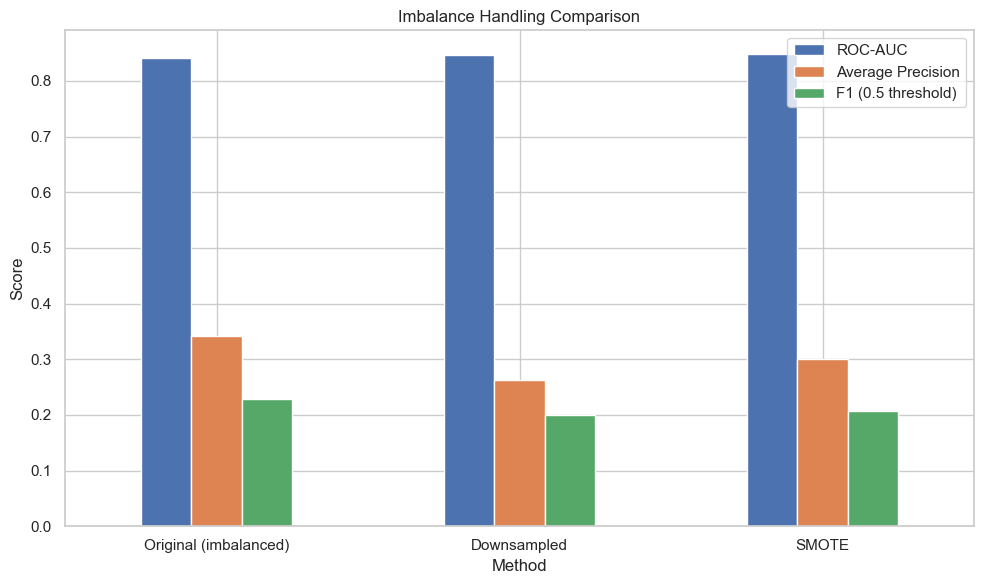

In [19]:
comparison = pd.DataFrame({
    'Method': ['Original (imbalanced)', 'Downsampled', 'SMOTE'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba),
        roc_auc_score(y_test, y_pred_proba_under),
        roc_auc_score(y_test, y_pred_proba_smote)
    ],
    'Average Precision': [
        average_precision_score(y_test, y_pred_proba),
        average_precision_score(y_test, y_pred_proba_under),
        average_precision_score(y_test, y_pred_proba_smote)
    ],
    'F1 (0.5 threshold)': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_under),
        f1_score(y_test, y_pred_smote)
    ]
})
print(comparison)

comparison.set_index('Method')[['ROC-AUC', 'Average Precision', 'F1 (0.5 threshold)']].plot(
    kind='bar', figsize=(10, 6))
plt.title('Imbalance Handling Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Threshold tuning

The reference project picks a decision threshold (instead of the default 0.5) by maximizing F1 on a holdout set. This can meaningfully improve fraud detection without changing the model at all — just where you draw the line between "fraud" and "not fraud."

Run this on whichever of the three models above performed best.

In [21]:
# Change this to whichever model/probabilities performed best above
best_proba = y_pred_proba_smote  # or y_pred_proba / y_pred_proba_under

precision, recall, thresholds = precision_recall_curve(y_test, best_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"F1 at best threshold: {f1_scores[best_idx]:.4f}")
print(f"F1 at default 0.5 threshold: {f1_score(y_test, (best_proba >= 0.5).astype(int)):.4f}")

y_pred_tuned = (best_proba >= best_threshold).astype(int)
print("\n=== Classification report at tuned threshold ===")
print(classification_report(y_test, y_pred_tuned))

Best threshold: 0.8412
F1 at best threshold: 0.3727
F1 at default 0.5 threshold: 0.2074

=== Classification report at tuned threshold ===
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98    113976
         1.0       0.37      0.38      0.37      4133

    accuracy                           0.96    118109
   macro avg       0.67      0.68      0.67    118109
weighted avg       0.96      0.96      0.96    118109



## 10. Takeaways to bring back to the team

Fill this in after running:
- Which method (original / downsampled / SMOTE) performed best on ROC-AUC and Average Precision?
- Did threshold tuning meaningfully improve F1 over the default 0.5 cutoff?
- Recommendation: should the team apply SMOTE or downsampling before training the final logistic regression / random forest models, or is the 3.5% imbalance mild enough to leave as-is?